In [1]:
# Wspólne definicje (jak w 20260716a/b/c.ipynb - kopiowane, nie importowane,
# żeby ten notebook był samodzielny). Cel tego notebooka: PIERWSZY krok z
# planu uzgodnionego z Homolą (komentarz z 2026-07-24, potwierdzony przez
# Maćka 2026-08-15, patrz źródła/odpowiedz_homola_20260815.txt) -
# odtworzenie wyniku artykułu przez pełny skan po t0 (nie tylko "burning
# sample"), osobno dla Moskwy i Oulu, jako kontrolny check przed
# rozszerzeniem na wszystkie 22 stacje NMDB.
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

sys.path.insert(0, "..")
from mc_parallel import run_t0_scan_parallel

USGS_PATH = "../data/usgs_data/usgs_m4_2005_2025.csv"

def load_earthquakes(min_mag=4.0):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()


def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


eq = load_earthquakes(min_mag=4.0)
print(f"EQ (M>=4.0): {len(eq)} zdarzeń, {eq.index.min()} .. {eq.index.max()}")


EQ (M>=4.0): 290945 zdarzeń, 2005-01-01 00:47:34.620000 .. 2025-01-31 23:57:39.481000


In [2]:
# Loadery CR. UWAGA: świadomie używamy PEŁNYCH, natywnych szeregów
# (mosc_data.csv 1960-2025, oulu_5min_data.csv 1970-2025 -> resample 6h),
# NIE danych `csv_data_stations_native6h/{mosc,oulu}_6h.csv` - te ostatnie
# to tylko wycinek 2011-2019 pobrany na potrzeby porównywalnej meta-analizy
# 22 stacji z 20260719b.ipynb i są za krótkie dla pełnego skanu po t0 na
# całym zakresie danych EQ (2005-01-01..2025-01-31, patrz CLAUDE.md).
MOSC_PATH = "../data/mosc_data.csv"
OULU_PATH = "../data/oulu_5min_data.csv"

def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_oulu():
    # Loader jak w 20260716b/c.ipynb: oulu_5min_data.csv ma jeden uszkodzony
    # wiersz (linia 839815, pole z bezsensownymi znakami zamiast daty, w
    # miejscu ~15-dniowej luki w danych z 1978 r.) - pomijamy go przez
    # errors="coerce" + dropna, zamiast czyścić plik źródłowy.
    df = pd.read_csv(OULU_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    n_bad = df["datetime"].isna().sum()
    if n_bad:
        print(f"load_oulu: pominięto {n_bad} niesparsowalnych wierszy (uszkodzone dane)")
    df = df.dropna(subset=["datetime"])
    return df.set_index("datetime").sort_index()["value"]


cr_mosc = load_mosc()
print(f"CR Moskwa (natywne 6h): {len(cr_mosc)} pomiarów, {cr_mosc.index.min()} .. {cr_mosc.index.max()}")

cr_oulu_5min = load_oulu()
cr_oulu = cr_oulu_5min.resample("6h").mean()
print(f"CR Oulu (5 min -> resample 6h): {len(cr_oulu)} pomiarów po resamplingu, "
      f"{cr_oulu.index.min()} .. {cr_oulu.index.max()}")


CR Moskwa (natywne 6h): 91824 pomiarów, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00
load_oulu: pominięto 1 niesparsowalnych wierszy (uszkodzone dane)
CR Oulu (5 min -> resample 6h): 81816 pomiarów po resamplingu, 1970-01-01 00:00:00 .. 2025-12-31 18:00:00


In [3]:
# Parametry skanu - PEŁNA konfiguracja zgodna z ustaleniami z Homolą
# (komentarz 2026-07-24, potwierdzone przez Maćka 2026-08-15 - patrz
# źródła/odpowiedz_homola_20260815.txt punkt 1):
#   - P_days = 3350          okno analizy (dni)
#   - krok t0 = 6h           natywna rozdzielczość obu stacji
#   - d_days w {1, 5}        szerokość binu (dni) - dwa osobne skany
#   - dt_days = 0            BEZ laga (Homola: lag "nie jest krytyczny"
#                             poza samplem, na którym był dostrojony w
#                             artykule)
#   - m = 4.0                próg magnitudy EQ (jak we wszystkich
#                             wcześniejszych notebookach tego repo)
#
# Zakres kandydatów t0: ograniczony przez dostępność danych EQ
# (usgs_m4_2005_2025.csv: 2005-01-01 00:47 .. 2025-01-31 23:57), bo to
# węższy zakres niż CR obu stacji. Wymóg: [t0, t0+P_days] w całości musi
# mieścić się w zakresie danych EQ (przy dt_days=0 to też dokładnie zakres
# potrzebny dla CR).
P_DAYS = 3350
D_VALUES = [1, 5]
DT_DAYS = 0
M_THRESHOLD = 4.0

t0_first = eq.index.min().ceil("6h")
t0_last = (eq.index.max() - pd.Timedelta(days=P_DAYS)).floor("6h")
t0_candidates = pd.date_range(t0_first, t0_last, freq="6h")

print(f"Zakres kandydatów t0: {t0_first} .. {t0_last}")
print(f"Liczba kandydatów t0: {len(t0_candidates)}")
print("(dla porównania: artykuł podaje 13400 kandydatów dla Moskwy, od "
      "30 marca 2005 - nasza liczba jest tego samego rzędu wielkości; "
      "różnica może wynikać z innego zakresu/wersji katalogu EQ użytego "
      "w artykule, nie jest to sprawdzone dokładnie)")


Zakres kandydatów t0: 2005-01-01 06:00:00 .. 2015-11-30 18:00:00
Liczba kandydatów t0: 15943
(dla porównania: artykuł podaje 13400 kandydatów dla Moskwy, od 30 marca 2005 - nasza liczba jest tego samego rzędu wielkości; różnica może wynikać z innego zakresu/wersji katalogu EQ użytego w artykule, nie jest to sprawdzone dokładnie)


In [4]:
# Wydajność: cosmoseismic_stat robi pd.cut na CAŁYM cr.index przy KAŻDYM
# wywołaniu (~16k razy na stację na wartość d), więc przycinamy cr/eq do
# minimalnego zakresu potrzebnego dla WSZYSTKICH kandydatów PRZED
# uruchomieniem skanu - to dokładnie [eq.index.min(), eq.index.max()],
# bo t0_first/t0_last zostały tak dobrane wyżej (przy dt_days=0 CR i EQ
# potrzebują tego samego zakresu). Sam skan jest zrównoleglony przez
# run_t0_scan_parallel (mc_parallel.py) - ten sam wzorzec (fork-based
# ProcessPoolExecutor) co dotychczasowe skany Monte Carlo w tym repo.
def clip_to_eq_range(series):
    return series[(series.index >= eq.index.min()) & (series.index <= eq.index.max())]

eq_clipped = eq  # eq samo definiuje zakres, nic do przycinania
cr_mosc_clipped = clip_to_eq_range(cr_mosc)
cr_oulu_clipped = clip_to_eq_range(cr_oulu)

print(f"cr_mosc: {len(cr_mosc)} -> {len(cr_mosc_clipped)} po przycięciu")
print(f"cr_oulu: {len(cr_oulu)} -> {len(cr_oulu_clipped)} po przycięciu")


cr_mosc: 91824 -> 28979 po przycięciu
cr_oulu: 81816 -> 29343 po przycięciu


In [5]:
# Pełny skan po t0 dla Moskwy, osobno dla d=1 i d=5. Wyniki (jeden wiersz
# na kandydata t0: N, N_valid, Np, Nm, PPDF, PCDF, sigma, t0) zapisywane od
# razu do results/ (CSV, niewersjonowany w git - patrz CLAUDE.md), żeby nie
# trzeba było liczyć od nowa przy kolejnych analizach (np. mapy cykl-do-cyklu
# z kolejnego kroku planu).
mosc_scan_results = {}
for d in D_VALUES:
    print(f"\n=== Moskwa, d={d} ===")
    t_start = time.time()
    df_scan = run_t0_scan_parallel(
        cr_mosc_clipped, eq_clipped, t0_candidates,
        P_days=P_DAYS, d_days=d, m=M_THRESHOLD, dt_days=DT_DAYS,
        stat_fn=cosmoseismic_stat,
        save_path=f"../results/t0_scan_mosc_d{d}.csv",
    )
    print(f"gotowe w {time.time() - t_start:.1f}s, {len(df_scan)} wierszy")
    mosc_scan_results[d] = df_scan



=== Moskwa, d=1 ===
gotowe w 309.6s, 15943 wierszy

=== Moskwa, d=5 ===
gotowe w 68.1s, 15943 wierszy


In [6]:
# To samo dla Oulu.
oulu_scan_results = {}
for d in D_VALUES:
    print(f"\n=== Oulu, d={d} ===")
    t_start = time.time()
    df_scan = run_t0_scan_parallel(
        cr_oulu_clipped, eq_clipped, t0_candidates,
        P_days=P_DAYS, d_days=d, m=M_THRESHOLD, dt_days=DT_DAYS,
        stat_fn=cosmoseismic_stat,
        save_path=f"../results/t0_scan_oulu_d{d}.csv",
    )
    print(f"gotowe w {time.time() - t_start:.1f}s, {len(df_scan)} wierszy")
    oulu_scan_results[d] = df_scan



=== Oulu, d=1 ===
gotowe w 308.5s, 15943 wierszy

=== Oulu, d=5 ===
gotowe w 69.2s, 15943 wierszy


In [7]:
# Ekstremalny PPDF (definicja "siły efektu" wg Homoli - komentarz z
# 2026-07-24, punkt 3: NIE sigma z MC w obecnym kształcie, tylko surowy
# PPDF z pełnego skanu po t0, dokładnie jak w artykule) dla każdej
# stacji/szerokości binu, porównany z:
#   - benchmarkiem Homoli: P_PDF < 1e-8 dla Moskwy (log10(PPDF) < -8)
#   - wartościami z artykułu przy ich zgłoszonym optimum (d=5):
#     Moskwa  t0=2013-11-14: N+=218, N-=113, PCDF=4.1e-9 (~6 sigma)
#     Oulu    t0=2014-01-04: N+=220, N-=112, PCDF=1.6e-9
#     (patrz 20260717.txt pkt 7 - to poprzednia, NIESKANOWANA replikacja
#     tych dokładnych t0, tutaj sprawdzamy czy pełny skan znajdzie coś
#     RÓWNIE lub BARDZIEJ ekstremalnego w całym zakresie kandydatów)
ARTICLE_REF = {
    ("mosc", 5): dict(t0=pd.Timestamp("2013-11-14"), Np=218, Nm=113, PCDF=4.1e-9),
    ("oulu", 5): dict(t0=pd.Timestamp("2014-01-04"), Np=220, Nm=112, PCDF=1.6e-9),
}
HOMOLA_LOG10_PPDF_BENCHMARK = -8

rows = []
for station, results in [("mosc", mosc_scan_results), ("oulu", oulu_scan_results)]:
    for d, df_scan in results.items():
        best = df_scan.loc[df_scan["PPDF"].idxmin()]
        rows.append(dict(
            station=station, d=d, t0_best=best["t0"],
            Np=int(best["Np"]), Nm=int(best["Nm"]),
            PPDF=best["PPDF"], PCDF=best["PCDF"], sigma=best["sigma"],
            log10_PPDF=np.log10(best["PPDF"]),
            beats_homola_benchmark=np.log10(best["PPDF"]) < HOMOLA_LOG10_PPDF_BENCHMARK,
        ))

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print(f"\nBenchmark Homoli: log10(PPDF) < {HOMOLA_LOG10_PPDF_BENCHMARK}")
print("\nDla porównania, wartości z artykułu przy ich zgłoszonym t0 (nieskanowane):")
for (station, d), ref in ARTICLE_REF.items():
    print(f"  {station} d={d}: t0={ref['t0'].date()}, Np={ref['Np']}, Nm={ref['Nm']}, PCDF={ref['PCDF']:.2e}")


station  d             t0_best   Np   Nm         PPDF         PCDF    sigma  log10_PPDF  beats_homola_benchmark
   mosc  1 2015-01-17 18:00:00 1765 1575 6.200974e-05 5.356514e-04 3.271099   -4.207540                   False
   mosc  5 2008-02-26 00:00:00  384  283 1.448502e-05 5.247789e-05 3.878840   -4.839081                   False
   oulu  1 2008-08-31 18:00:00 1796 1550 1.621567e-06 1.131245e-05 4.237275   -5.790065                   False
   oulu  5 2006-01-26 12:00:00  414  253 9.550528e-11 2.411207e-10 6.224777  -10.019973                    True

Benchmark Homoli: log10(PPDF) < -8

Dla porównania, wartości z artykułu przy ich zgłoszonym t0 (nieskanowane):
  mosc d=5: t0=2013-11-14, Np=218, Nm=113, PCDF=4.10e-09
  oulu d=5: t0=2014-01-04, Np=220, Nm=112, PCDF=1.60e-09


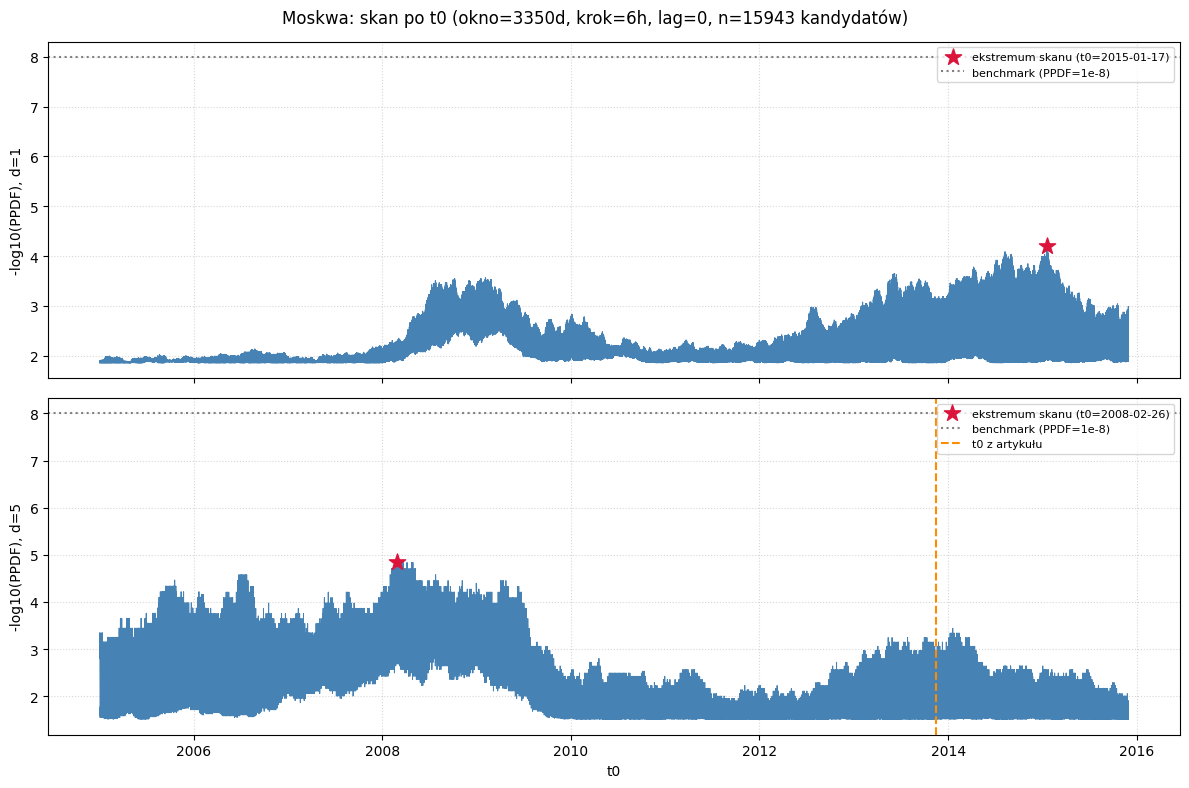

In [10]:
# Kontrolny wykres PPDF vs t0 dla Moskwy (wymagany przez Homolę,
# komentarz 2026-07-24, punkt "control-check"), osobno d=1/d=5. Oś Y:
# -log10(PPDF) (im wyżej, tym silniejszy efekt). Linia pozioma: benchmark
# Homoli (log10(PPDF)=-8). Linia pionowa przerywana: t0 zgłoszone w
# artykule jako optimum dla d=5 (2013-11-14).
fig, axes = plt.subplots(len(D_VALUES), 1, figsize=(12, 8), sharex=True)
for ax, d in zip(np.atleast_1d(axes), D_VALUES):
    df_scan = mosc_scan_results[d]
    ax.plot(df_scan["t0"], -np.log10(df_scan["PPDF"]), lw=0.7, color="steelblue")
    best = df_scan.loc[df_scan["PPDF"].idxmin()]
    ax.scatter([best["t0"]], [-np.log10(best["PPDF"])], color="crimson", zorder=5,
               marker="*", s=150, label=f"ekstremum skanu (t0={pd.Timestamp(best['t0']).date()})")
    ax.axhline(-HOMOLA_LOG10_PPDF_BENCHMARK, color="gray", ls=":", label="benchmark (PPDF=1e-8)")
    if ("mosc", d) in ARTICLE_REF:
        ax.axvline(ARTICLE_REF[("mosc", d)]["t0"], color="darkorange", ls="--",
                   label="t0 z artykułu")
    ax.set_ylabel(f"-log10(PPDF), d={d}")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(ls=":", alpha=0.5)
axes[-1].set_xlabel("t0")
fig.suptitle(f"Moskwa: skan po t0 (okno={P_DAYS}d, krok=6h, lag=0, n={len(t0_candidates)} kandydatów)")
fig.tight_layout()
fig.savefig("../results/t0_scan_mosc_plot.png", dpi=120)
plt.show()


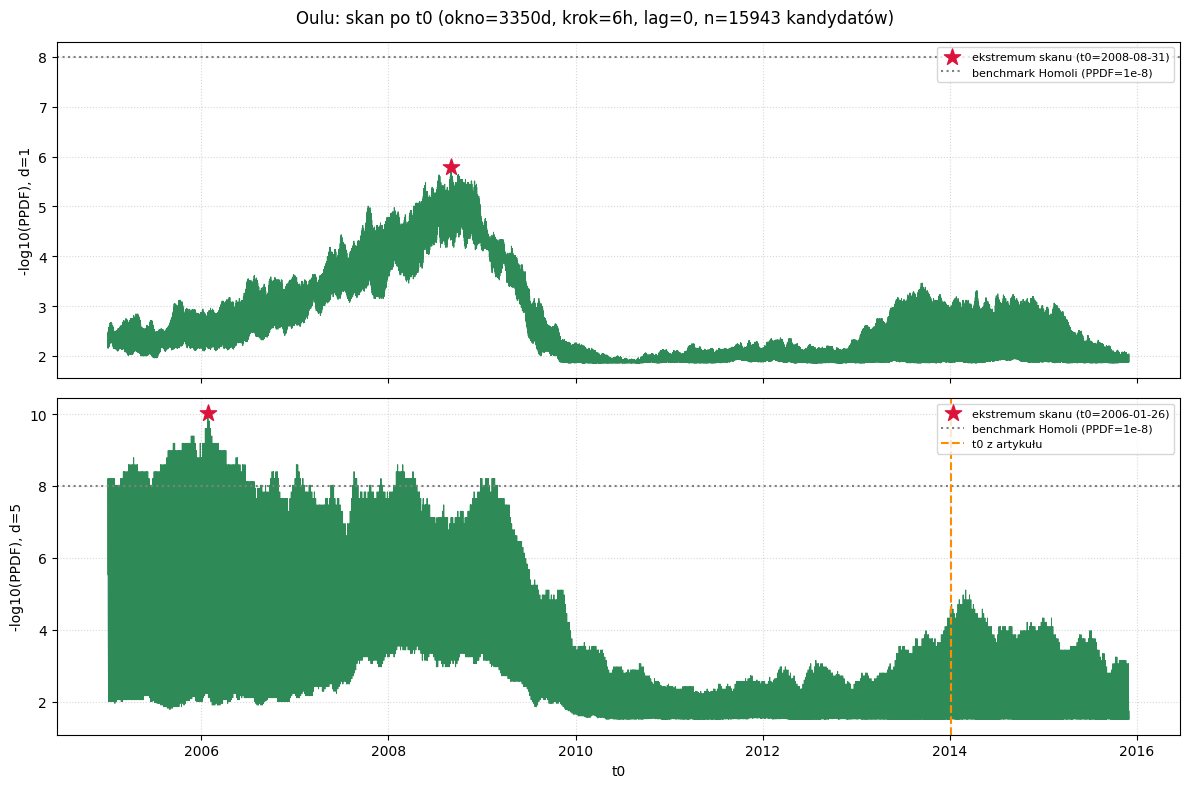

In [9]:
# To samo dla Oulu.
fig, axes = plt.subplots(len(D_VALUES), 1, figsize=(12, 8), sharex=True)
for ax, d in zip(np.atleast_1d(axes), D_VALUES):
    df_scan = oulu_scan_results[d]
    ax.plot(df_scan["t0"], -np.log10(df_scan["PPDF"]), lw=0.7, color="seagreen")
    best = df_scan.loc[df_scan["PPDF"].idxmin()]
    ax.scatter([best["t0"]], [-np.log10(best["PPDF"])], color="crimson", zorder=5,
               marker="*", s=150, label=f"ekstremum skanu (t0={pd.Timestamp(best['t0']).date()})")
    ax.axhline(-HOMOLA_LOG10_PPDF_BENCHMARK, color="gray", ls=":", label="benchmark Homoli (PPDF=1e-8)")
    if ("oulu", d) in ARTICLE_REF:
        ax.axvline(ARTICLE_REF[("oulu", d)]["t0"], color="darkorange", ls="--",
                   label="t0 z artykułu")
    ax.set_ylabel(f"-log10(PPDF), d={d}")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(ls=":", alpha=0.5)
axes[-1].set_xlabel("t0")
fig.suptitle(f"Oulu: skan po t0 (okno={P_DAYS}d, krok=6h, lag=0, n={len(t0_candidates)} kandydatów)")
fig.tight_layout()
fig.savefig("../results/t0_scan_oulu_plot.png", dpi=120)
plt.show()
